## 1단계. 데이터 확인

In [1]:
import pandas as pd

df = pd.read_csv("../data/online_retail.csv")

In [2]:
df.info()   # 데이터 구조 파악

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [3]:
df.head()   # 데이터 샘플 확인

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 8:26,3.39,17850.0,United Kingdom


In [4]:
df.isnull().sum()   # 결측치 확인

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df[df["Quantity"] < 0]  # 환불 데이터 확인

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58,1.25,17315.0,United Kingdom


## 2단계. 데이터 정제

In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])   # 날짜형 변환

df = df.dropna(subset=["CustomerID"])   # CustomerID가 없는 데이터 제거

df = df[df["Quantity"] > 0]     # 환불 데이터 제거
df = df[df["UnitPrice"] > 0]    # 가격 이상치 제거


df["CustomerID"] = df["CustomerID"].astype(int)  # int로 타입 변환
df["Sales"] = df["Quantity"] * df["UnitPrice"]  # Sales 컬럼 생성

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   Sales        397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [7]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
# 년, 월, 일, 시간 컬럼 생성

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8


## 3단계. EDA(Exploratory Data Analysis)

In [8]:
# 가장 많이 팔린 상품 TOP 10
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [9]:
# 매출 기준 TOP 10
top_sales_products = df.groupby("Description")["Sales"].sum().sort_values(ascending=False).head(10)
top_sales_products 

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Sales, dtype: float64

In [10]:
# 국가별 매출 순위
sales_by_country = df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

sales_by_country.head(10) 

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64

In [11]:
# 국가별 주문 수
orders_by_country = df["Country"].value_counts()
orders_by_country.head(10)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

In [12]:
# 월별 매출 추이
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum()
monthly_sales

Year  Month
2010  12        572713.890
2011  1         569445.040
      2         447137.350
      3         595500.760
      4         469200.361
      5         678594.560
      6         661213.690
      7         600091.011
      8         645343.900
      9         952838.382
      10       1039318.790
      11       1161817.380
      12        518192.790
Name: Sales, dtype: float64

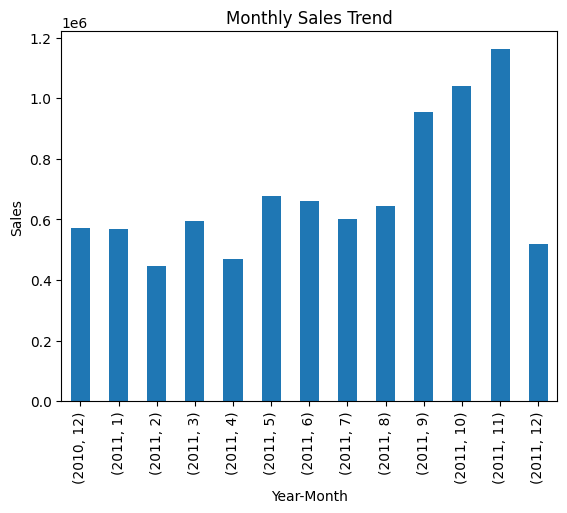

In [13]:
# 월별 매출 그래프
import matplotlib.pyplot as plt

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")

plt.show()

In [14]:
# 시간대별 주문 분석
sales_by_hour = df.groupby("Hour")["InvoiceNo"].count()
sales_by_hour

Hour
6         1
7       379
8      8690
9     21944
10    37997
11    49084
12    72065
13    64026
14    54118
15    45369
16    24089
17    13071
18     2928
19     3321
20      802
Name: InvoiceNo, dtype: int64

In [15]:
# 고객별 매출 분석
customer_sales = df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False)
customer_sales.head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: Sales, dtype: float64

In [16]:
# 고객별 주문 횟수 분포 확인
orders_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()
orders_per_customer.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

In [17]:
# 주문 1건당 평균 결제 금액
avg_order_value = df.groupby("InvoiceNo")["Sales"].sum().mean()
avg_order_value

np.float64(480.8659563997409)

## 4단계. RFM 고객 분석

RFM 분석은 고객별 최근 구매일(Recency), 주문 빈도(Frequency), 총 구매금액(Monetary)을 기준으로 고객 가치를 평가하는 방법이다.

In [18]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)      # 가장 최근 주문 날짜를 찾아 + 1일을 해서 기준 날짜를 지정

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,    # 마지막 구매 후 며칠이 지났는지
    "InvoiceNo": "nunique",     # 해당 고객이 몇 번 주문했는지(주문 횟수)
    "Sales": "sum"      # 해당 고객이 지금까지 총 얼마를 구매했는지(총 매출)
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [19]:
# Recency 점수 만들기
# Recency가 작을수록 최근에 구매한 고객이므로 높은 점수를 부여
# qcut() : 데이터를 n등분해서 각 그룹에 같은 개수를 넣음
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm.head()

,Recency,Frequency,Monetary,R_score
CustomerID,,,,
12346,326,1,77183.60,1
12347,2,7,4310.00,5
12348,75,4,1797.24,2
12349,19,1,1757.55,4
12350,310,1,334.40,1


In [20]:
# Frequency 점수 만들기
# Frequency가 클수록 주문을 많이한 고객
# rank(method="first") : 중복값을 순서대로 나눠서 고유값으로 만듦(중복 제거)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]) 
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score
CustomerID,,,,,
12346,326,1,77183.60,1,1
12347,2,7,4310.00,5,5
12348,75,4,1797.24,2,4
12349,19,1,1757.55,4,1
12350,310,1,334.40,1,1


In [21]:
# Monetary 점수 만들기
# Monetary가 클수록 돈을 많이 쓴 고객
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346,326,1,77183.60,1,1,5
12347,2,7,4310.00,5,5,5
12348,75,4,1797.24,2,4,4
12349,19,1,1757.55,4,1,4
12350,310,1,334.40,1,1,2


In [22]:
# RFM 점수 합치기
rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


In [23]:
# VIP 고객 찾기
rfm[rfm["RFM_score"] == "555"]

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12347,2,7,4310.00,5,5,5,555
12362,3,10,5226.23,5,5,5,555
12417,3,9,3649.10,5,5,5,555
12433,1,7,13375.87,5,5,5,555
12437,2,18,4951.41,5,5,5,555
...,...,...,...,...,...,...,...
18230,9,7,2810.20,5,5,5,555
18241,10,17,2073.09,5,5,5,555
18245,7,7,2567.06,5,5,5,555


In [24]:
# 돈 많이 쓰는 고객 TOP 10
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
14646,2,73,280206.02,5,5,5,555
18102,1,60,259657.30,5,5,5,555
17450,8,46,194550.79,5,5,5,555
16446,1,2,168472.50,5,3,5,535
14911,1,201,143825.06,5,5,5,555
12415,24,21,124914.53,4,5,5,455
14156,10,55,117379.63,5,5,5,555
17511,3,31,91062.38,5,5,5,555
16029,39,63,81024.84,3,5,5,355


In [25]:
# 다양한 고객 그룹 확인
rfm["RFM_score"].value_counts().head(10)

# 555 : VIP 고객 (유지해야함)
# 111 : 이탈 고객 (거의 활동 없음, 마케팅 대상)
# 511 : 최근에 왔지만 적게 산 고객
# 155 : 과거 VIP (재유입 대상)

RFM_score
555    348
111    183
455    178
121    153
112    128
444    122
122     92
544     88
233     85
344     83
Name: count, dtype: int64

## 5단계. 고객 세그먼트 만들기

RFM 점수를 바탕으로 고객을 VIP, Recent, Loyal, Big Spender, Normal 그룹으로 구분하였다.

In [26]:
# 고객 세그먼트 생성
def segment_customer(row):
    if row["RFM_score"] == "555":
        return "VIP"    # VIP 고객
    elif row["RFM_score"][0] == "5":
        return "Recent"     # 최근 구매한 고객
    elif row["RFM_score"][1] == "5": 
        return "Loyal"      # 자주 구매한 고객
    elif row["RFM_score"][2] == "5":
        return "Big Spender"    # 돈을 많이 쓴 고객
    else:
        return "Normal"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)
rfm["Segment"].value_counts()

Segment
Normal         2860
Recent          520
Loyal           429
VIP             348
Big Spender     181
Name: count, dtype: int64

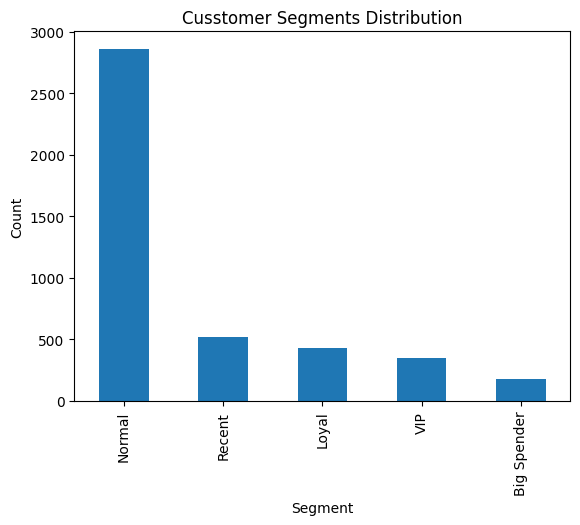

In [27]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Cusstomer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

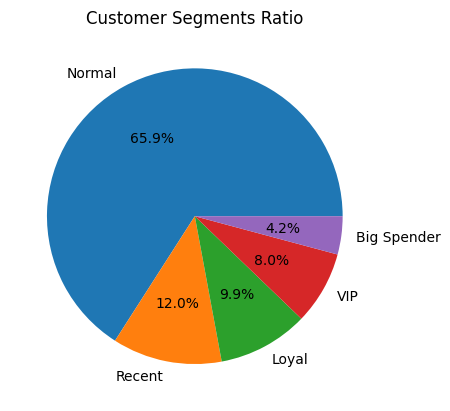

In [28]:
rfm["Segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Segments Ratio")
plt.ylabel("")
plt.show()


In [29]:
# VIP와 Normal 비교
vip = rfm[rfm["Segment"] == "VIP"]
normal = rfm[rfm["Segment"] == "Normal"]

comparison = pd.DataFrame({
    "VIP" : vip[["Recency", "Frequency", "Monetary"]].mean(),
    "Normal" : normal[["Recency", "Frequency", "Monetary"]].mean()
})
comparison["Ratio(VIP/Normal)"] = comparison["VIP"] / comparison["Normal"]

comparison
# VIP 고객은 일반 고객 대비 구매 빈도는 약 9.4배, 구매 금액은 약 19.5배 높은 특징을 보인다.

,VIP,Normal,Ratio(VIP/Normal)
Recency,5.445402,126.751748,0.042961
Frequency,18.241379,1.939860,9.403451
Monetary,11221.741121,572.736879,19.593188


## 6단계 : 데이터 마트 구조 만들기

In [30]:
# 거래 테이블 - 거래 기록(언제, 누가, 무엇을 샀는지)
fact_sales = df[[
    "InvoiceNo",
    "CustomerID",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Sales",
    "InvoiceDate"
]].copy()

fact_sales.head()


,InvoiceNo,CustomerID,StockCode,Quantity,UnitPrice,Sales,InvoiceDate
0,536365,17850,85123A,6,2.55,15.30,2010-12-01 08:26:00
1,536365,17850,71053,6,3.39,20.34,2010-12-01 08:26:00
2,536365,17850,84406B,8,2.75,22.00,2010-12-01 08:26:00
3,536365,17850,84029G,6,3.39,20.34,2010-12-01 08:26:00
4,536365,17850,84029E,6,3.39,20.34,2010-12-01 08:26:00


In [31]:
# 고객 테이블 - 고객 정보 + RFM + Segment
dim_customer = rfm.reset_index()

dim_customer.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,12346,326,1,77183.60,1,1,5,115,Big Spender
1,12347,2,7,4310.00,5,5,5,555,VIP
2,12348,75,4,1797.24,2,4,4,244,Normal
3,12349,19,1,1757.55,4,1,4,414,Normal
4,12350,310,1,334.40,1,1,2,112,Normal


In [32]:
# 상품 테이블 - 상품 정보
dim_product = df[[
    "StockCode",
    "Description"
]].drop_duplicates()

dim_product.head()

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,71053,WHITE METAL LANTERN
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.


In [33]:
# VIP 고객이 많이 산 상품 TOP 10
vip_ids = dim_customer[dim_customer["Segment"] == "VIP"]["CustomerID"]
# VIP 고객 ID만 추출
vip_sales = fact_sales[fact_sales["CustomerID"].isin(vip_ids)]
# VIP 고객의 거래만 필터링
vip_product = (
    vip_sales.groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)   # 상품별로 묶은 후, 판매량 합계, 많이 팔린 순 정렬, TOP 10   

vip_product

StockCode
84077     28631
22197     27882
85099B    25027
85123A    17855
22616     14892
21212     14619
23084     12699
22178     12582
21977     12304
84879     12297
Name: Quantity, dtype: int64

In [34]:
vip_product_detail = vip_product.reset_index().merge(
    dim_product,
    on="StockCode",
    how="left"
)

# StockCode를 기준으로 left join

vip_product_detail

,StockCode,Quantity,Description
0,84077,28631,WORLD WAR 2 GLIDERS ASSTD DESIGNS
1,22197,27882,SMALL POPCORN HOLDER
2,22197,27882,POPCORN HOLDER
3,85099B,25027,JUMBO BAG RED RETROSPOT
4,85123A,17855,WHITE HANGING HEART T-LIGHT HOLDER
5,85123A,17855,CREAM HANGING HEART T-LIGHT HOLDER
6,22616,14892,PACK OF 12 LONDON TISSUES
7,21212,14619,PACK OF 72 RETROSPOT CAKE CASES
8,23084,12699,RABBIT NIGHT LIGHT
9,22178,12582,VICTORIAN GLASS HANGING T-LIGHT
